# Gradient-Based Calibration (4 Parameters, No QE)

This notebook optimizes 4 scalar detector parameters (`scatter_length`, `wall_reflection_rate`, `sensor_reflection_rate`, `absorption_length`) while keeping `qe` and `qe_corrections` frozen.

In [1]:
import sys
sys.path.append('../')
from lucid.geometry import generate_detector
from lucid.losses import WC_smooth_loss
from lucid.simulation import setup_event_simulator
from lucid.detector_params import (
    DetectorParams, laser_source,
    normalize_params, denormalize_params, default_bounds,
    make_optimization_mask, load_detector_params,
)
import jax
import jax.numpy as jnp
from jax import value_and_grad, jit
import optax
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import time

/home/NahuelBrito21/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-pzjtx3yc because there was an issue with the default path (/home/NahuelBrito21/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
default_json_filename = '../config/SK_geom_config.json'
detector = generate_detector(default_json_filename)
detector_points = jnp.array(detector.all_points)
NUM_DETECTORS = len(detector_points)

Nphot = 500_000
K = 8
Nphot_True = 15_000_000
K_True = 12

# True detector params — explicit physical values for scalar-mode calibration
TRUE_PARAMS = DetectorParams(
    scatter_length=jnp.array(50.0),
    wall_reflection_rate=jnp.array(0.2),
    sensor_reflection_rate=jnp.array(0.2),
    absorption_length=jnp.array(50.0),
    qe=jnp.array(0.065),
    qe_corrections=jnp.ones(NUM_DETECTORS),
)

# Bounds for normalization — tighten lower bounds to prevent params going to zero
bounds_min, bounds_max = default_bounds(NUM_DETECTORS)
bounds_min = bounds_min._replace(
    scatter_length=jnp.array(5.0),
    wall_reflection_rate=jnp.array(0.05),
    sensor_reflection_rate=jnp.array(0.05),
    absorption_length=jnp.array(10.0),
)

# Trainable fields (freeze qe and qe_corrections)
TRAINABLE_FIELDS = {'scatter_length', 'wall_reflection_rate', 'sensor_reflection_rate', 'absorption_length'}

# Source
source = laser_source(position=[0.0, 0.0, detector.H / 2 - 0.1], intensity=100_000_000)

# Optimizer hyperparams
ADAM_LEARNING_RATE = 0.05
ADAM_ITERATIONS = 500
WARMUP_FRACTION = 0.4
N_INIT_GUESSES = 1
INIT_FRAC_DIFF = 0.5

COLORS = ['#0077BB', '#EE7733', '#009988', '#EE3377', '#33BBEE', '#CC3311']

In [3]:
simulate_event = setup_event_simulator(
    default_json_filename, Nphot, temperature=None, K=K,
    is_data=False, is_calibration=True, hit_mode='aggregated',
    wavelength_mode=False,
)
simulate_data = setup_event_simulator(
    default_json_filename, Nphot_True, temperature=None, K=K_True,
    is_data=False, is_calibration=True, hit_mode='aggregated',
    default_detector_params=TRUE_PARAMS,
    wavelength_mode=False,
)

In [4]:
key = jax.random.PRNGKey(42)
key_source, key_data, key_init = jax.random.split(key, 3)

print("Generating true data...")
true_data = jax.lax.stop_gradient(simulate_data(source, key_data))
print(f"Active sensors: {int(jnp.sum(true_data[0] > 0))}")

def generate_initial_guesses(true_params, n_guesses, frac_diff, key):
    guesses = []
    for i in range(n_guesses):
        key, subkey = jax.random.split(key)
        mults = jax.random.uniform(subkey, shape=(4,), minval=1-frac_diff, maxval=1+frac_diff)
        # Create perturbed DetectorParams — only vary trainable fields
        guess = DetectorParams(
            scatter_length=jnp.clip(true_params.scatter_length * mults[0], 0.01, 100.0),
            wall_reflection_rate=jnp.clip(true_params.wall_reflection_rate * mults[1], 0.01, 0.5),
            sensor_reflection_rate=jnp.clip(true_params.sensor_reflection_rate * mults[2], 0.01, 0.4),
            absorption_length=jnp.clip(true_params.absorption_length * mults[3], 0.01, 500.0),
            qe=true_params.qe,
            qe_corrections=true_params.qe_corrections,
        )
        guesses.append(guess)
    return guesses

initial_guesses = generate_initial_guesses(TRUE_PARAMS, N_INIT_GUESSES, INIT_FRAC_DIFF, key_init)
print(f"Generated {len(initial_guesses)} initial guesses")

Generating true data...
Active sensors: 11096
Generated 1 initial guesses


In [5]:
def create_loss_function(source, true_data, key):
    @jit
    def loss_fn(detector_params):
        simulated_data = simulate_event(source, detector_params, key)
        return WC_smooth_loss(
            detector_points, *true_data, *simulated_data,
            lambda_poisson=1.0, lambda_time=0.0, tau=1.0
        )
    return loss_fn

loss_fn = create_loss_function(source, true_data, key_source)

# Define once at cell level — avoids recompilation per init guess
@jit
def step_fn(params):
    return value_and_grad(lambda p: loss_fn(denormalize_params(p, bounds_min, bounds_max)))(params)

In [6]:
def run_single_optimization(initial_guess, loss_fn, guess_idx=0):
    print(f"\n--- Initial Guess {guess_idx+1} ---")
    print(f"  Scatter: {float(initial_guess.scatter_length):.2f} m (true: {float(TRUE_PARAMS.scatter_length):.2f})")
    print(f"  Wall Refl: {float(initial_guess.wall_reflection_rate):.3f} (true: {float(TRUE_PARAMS.wall_reflection_rate):.3f})")
    print(f"  Sensor Refl: {float(initial_guess.sensor_reflection_rate):.3f} (true: {float(TRUE_PARAMS.sensor_reflection_rate):.3f})")
    print(f"  Absorption: {float(initial_guess.absorption_length):.2f} m (true: {float(TRUE_PARAMS.absorption_length):.2f})")
    
    # Normalize to [0,1]
    params = normalize_params(initial_guess, bounds_min, bounds_max)
    
    # Warmup schedule
    warmup_steps = int(WARMUP_FRACTION * ADAM_ITERATIONS)
    lr_schedule = optax.warmup_constant_schedule(
        init_value=0.0, peak_value=ADAM_LEARNING_RATE, warmup_steps=warmup_steps
    )
    
    # multi_transform: Adam for trainable, set_to_zero for frozen
    mask = make_optimization_mask(params, TRAINABLE_FIELDS)
    param_labels = jax.tree.map(lambda m: 'train' if m else 'freeze', mask)
    optimizer = optax.multi_transform({
        'train': optax.adam(learning_rate=lr_schedule, b1=0.95, b2=0.99),
        'freeze': optax.set_to_zero(),
    }, param_labels)
    opt_state = optimizer.init(params)
    
    losses = []
    param_history = []
    gradient_norms = []
    
    start_time = time.time()
    pbar = tqdm(range(ADAM_ITERATIONS))
    
    for iteration in pbar:
        loss_val, grad_val = step_fn(params)
        updates, opt_state = optimizer.update(grad_val, opt_state)
        params = optax.apply_updates(params, updates)
        # Clip normalized params to [0, 1]
        params = jax.tree.map(lambda x: jnp.clip(x, 0.01, 0.99), params)
        
        losses.append(float(loss_val))
        denorm = denormalize_params(params, bounds_min, bounds_max)
        param_history.append(denorm)
        grad_leaves = jax.tree.leaves(grad_val)
        gradient_norms.append(float(jnp.sqrt(sum(jnp.sum(g**2) for g in grad_leaves))))
        
        true_arr = jnp.array([float(TRUE_PARAMS.scatter_length), float(TRUE_PARAMS.wall_reflection_rate),
                              float(TRUE_PARAMS.sensor_reflection_rate), float(TRUE_PARAMS.absorption_length)])
        curr_arr = jnp.array([float(denorm.scatter_length), float(denorm.wall_reflection_rate),
                              float(denorm.sensor_reflection_rate), float(denorm.absorption_length)])
        mse = float(jnp.mean((curr_arr - true_arr) ** 2))
        pbar.set_postfix(loss=f"{float(loss_val):.4f}", mse=f"{mse:.6f}")
    
    runtime = time.time() - start_time
    final_params = denormalize_params(params, bounds_min, bounds_max)
    
    final_arr = jnp.array([float(final_params.scatter_length), float(final_params.wall_reflection_rate),
                           float(final_params.sensor_reflection_rate), float(final_params.absorption_length)])
    param_errors = jnp.abs(final_arr - true_arr)
    final_mse = float(jnp.mean(param_errors ** 2))
    
    print(f"  Final Loss: {losses[-1]:.6f}")
    print(f"  MSE: {final_mse:.6f}")
    
    return {
        'final_params': final_params,
        'final_loss': losses[-1],
        'losses': jnp.array(losses),
        'param_history': param_history,
        'gradient_norms': jnp.array(gradient_norms),
        'param_errors': param_errors,
        'mse': final_mse,
        'runtime': runtime,
        'initial_guess': initial_guess,
    }

In [7]:
true_arr = jnp.array([float(TRUE_PARAMS.scatter_length), float(TRUE_PARAMS.wall_reflection_rate),
                      float(TRUE_PARAMS.sensor_reflection_rate), float(TRUE_PARAMS.absorption_length)])

In [8]:
results_list = []
print(f"Running {N_INIT_GUESSES} optimization runs...")

for idx, initial_guess in enumerate(initial_guesses):
    results = run_single_optimization(initial_guess, loss_fn, guess_idx=idx)
    results_list.append(results)

Running 1 optimization runs...

--- Initial Guess 1 ---
  Scatter: 36.49 m (true: 50.00)
  Wall Refl: 0.155 (true: 0.200)
  Sensor Refl: 0.184 (true: 0.200)
  Absorption: 58.68 m (true: 50.00)


100%|██████████████████████████████████████████████████████| 500/500 [01:25<00:00,  5.84it/s, loss=0.0198, mse=0.025494]


  Final Loss: 0.019752
  MSE: 0.025494


In [9]:
print("\n" + "=" * 100)
print("OPTIMIZATION SUMMARY")
print("=" * 100)
print(f"Configuration: 4 Parameters (No QE), optax.masked + Warmup LR")
print(f"Init Fraction Diff = {INIT_FRAC_DIFF}, Guesses = {N_INIT_GUESSES}")
print(f"Peak LR = {ADAM_LEARNING_RATE}, Iterations = {ADAM_ITERATIONS}")
print("-" * 100)
print(f"{'Guess':<8} {'Final Loss':<12} {'MSE':<12} {'Runtime (s)':<12}")
print("-" * 100)

for idx, r in enumerate(results_list):
    print(f"{idx+1:<8} {r['final_loss']:<12.6f} {r['mse']:<12.6f} {r['runtime']:<12.2f}")

best_idx = np.argmin([r['final_loss'] for r in results_list])
print("-" * 100)
print(f"Best: Guess {best_idx+1} with loss {results_list[best_idx]['final_loss']:.6f}")

best = results_list[best_idx]
pnames = ['Scatter', 'Wall Refl', 'Sensor Refl', 'Absorption']
final_arr = [float(best['final_params'].scatter_length), float(best['final_params'].wall_reflection_rate),
             float(best['final_params'].sensor_reflection_rate), float(best['final_params'].absorption_length)]
print(f"\n{'Parameter':<15} {'True':<12} {'Final':<12} {'Error':<12}")
for i, name in enumerate(pnames):
    print(f"{name:<15} {true_arr[i]:<12.4f} {final_arr[i]:<12.4f} {abs(final_arr[i]-true_arr[i]):<12.4f}")


OPTIMIZATION SUMMARY
Configuration: 4 Parameters (No QE), optax.masked + Warmup LR
Init Fraction Diff = 0.5, Guesses = 1
Peak LR = 0.05, Iterations = 500
----------------------------------------------------------------------------------------------------
Guess    Final Loss   MSE          Runtime (s) 
----------------------------------------------------------------------------------------------------
1        0.019752     0.025494     85.57       
----------------------------------------------------------------------------------------------------
Best: Guess 1 with loss 0.019752

Parameter       True         Final        Error       
Scatter         50.0000      49.7783      0.2217      
Wall Refl       0.2000       0.2029       0.0029      
Sensor Refl     0.2000       0.1847       0.0153      
Absorption      50.0000      50.2293      0.2293      


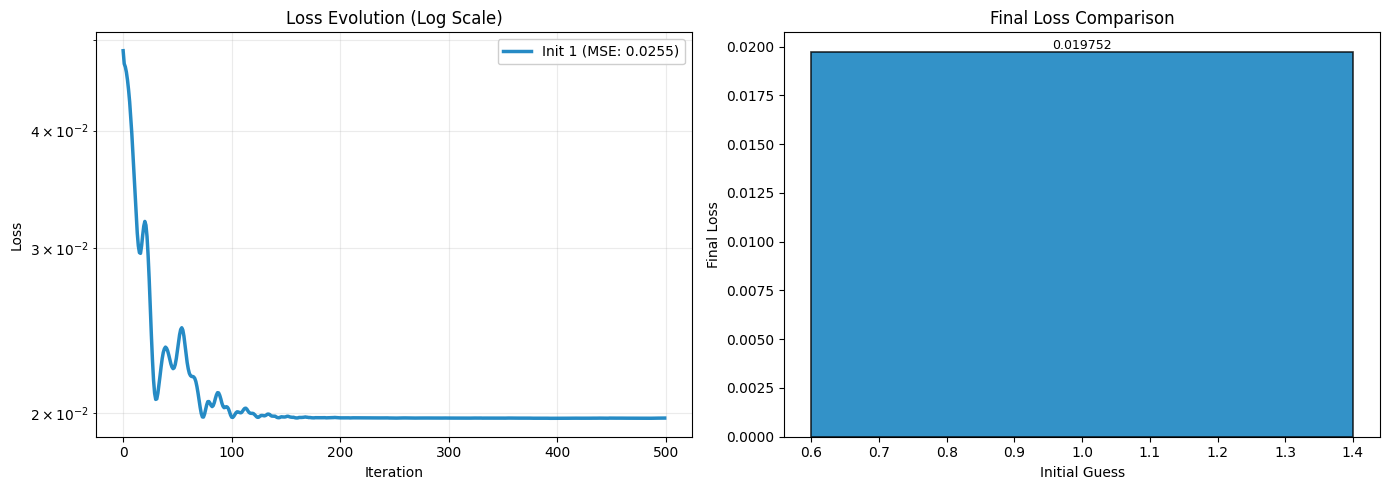

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for idx, results in enumerate(results_list):
    color = COLORS[idx % len(COLORS)]
    ax1.plot(range(len(results['losses'])), results['losses'],
             color=color, linewidth=2.5, alpha=0.85,
             label=f'Init {idx+1} (MSE: {results["mse"]:.4f})')

ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Evolution (Log Scale)')
ax1.set_yscale('log')
ax1.legend(loc='upper right', framealpha=0.95)
ax1.grid(True, which='both', alpha=0.25)

final_losses = [r['final_loss'] for r in results_list]
bars = ax2.bar(range(1, len(results_list)+1), final_losses,
               color=[COLORS[i % len(COLORS)] for i in range(len(results_list))],
               alpha=0.8, edgecolor='black', linewidth=1.2)
for bar, loss in zip(bars, final_losses):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{loss:.6f}', ha='center', va='bottom', fontsize=9)
ax2.set_xlabel('Initial Guess')
ax2.set_ylabel('Final Loss')
ax2.set_title('Final Loss Comparison')

plt.tight_layout()
plt.savefig('figures/multi_init_no_qe_loss_evolution_v2.png', dpi=300, bbox_inches='tight')
plt.show()

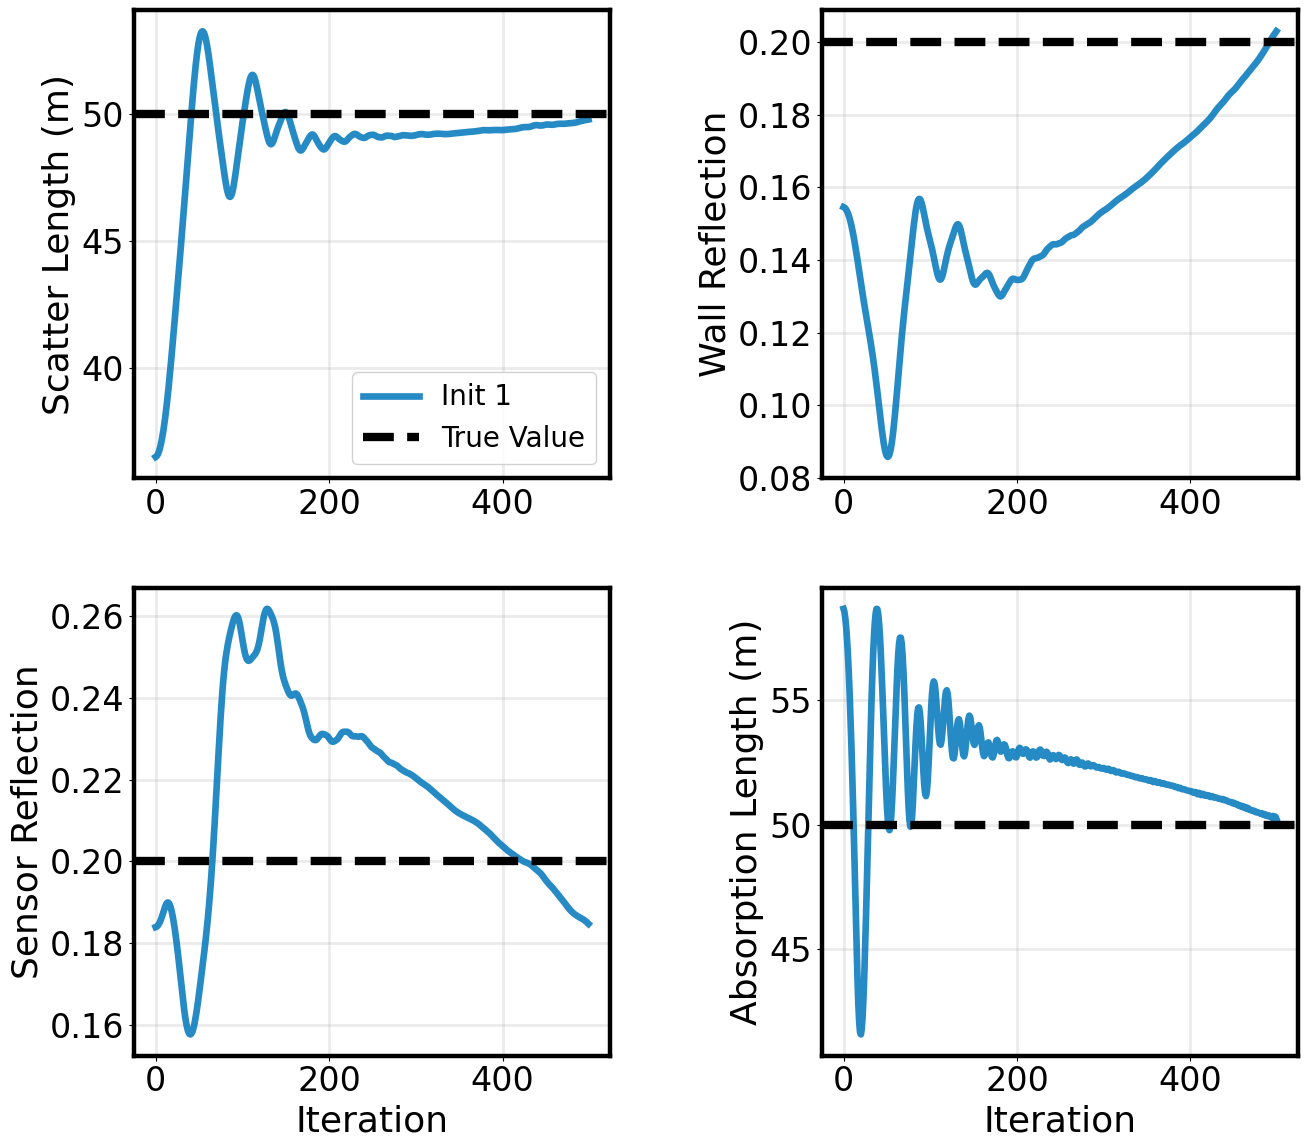

In [11]:
plt.rcParams.update({
    'font.size': 24, 'axes.labelsize': 26, 'xtick.labelsize': 24,
    'ytick.labelsize': 24, 'legend.fontsize': 20,
    'axes.linewidth': 3.2, 'grid.alpha': 0.3, 'grid.linewidth': 2.0
})

param_plot_names = ['Scatter Length (m)', 'Wall Reflection', 'Sensor Reflection', 'Absorption Length (m)']
param_plot_fields = ['scatter_length', 'wall_reflection_rate', 'sensor_reflection_rate', 'absorption_length']
true_plot_vals = true_arr

fig, axes = plt.subplots(2, 2, figsize=(13.6, 12.0))
axes = axes.flatten()

for pidx, (pname, field) in enumerate(zip(param_plot_names, param_plot_fields)):
    ax = axes[pidx]
    for gidx, results in enumerate(results_list):
        vals = [float(getattr(ph, field)) for ph in results['param_history']]
        ax.plot(range(len(vals)), vals, color=COLORS[gidx % len(COLORS)],
                linewidth=4.8, alpha=0.85, label=f'Init {gidx+1}')
    ax.axhline(y=true_plot_vals[pidx], color='black', linestyle='--', linewidth=6.0, label='True Value')
    if pidx >= 2:
        ax.set_xlabel('Iteration')
    ax.set_ylabel(pname)
    ax.grid(True, alpha=0.25)
    if pidx == 0:
        ax.legend(loc='best', framealpha=0.9)

plt.tight_layout(w_pad=2, h_pad=2)
plt.savefig('figures/multi_init_no_qe_parameter_evolution_v2.png', dpi=600, bbox_inches='tight', pad_inches=0.3)
plt.savefig('figures/multi_init_no_qe_parameter_evolution_v2.pdf', format='pdf', bbox_inches='tight', pad_inches=0.3)
plt.show()